# Care Transition Efficiency & Placement Outcome Analytics
### UAC Program — Exploratory Data Analysis & Metric Engineering

This notebook builds the analytical foundation for the project:
1. Load & clean the raw dataset
2. Model the care pipeline (CBP custody → HHS care → discharge)
3. Build transition efficiency metrics
4. Detect backlogs / delays
5. Temporal pattern analysis
6. Outcome stability analysis
7. Final KPI table (feeds the Streamlit app later)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load Data

In [2]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
print(df.shape)
df.head(10)


(1170, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0
5,"December 14, 2025",8.0,35.0,4.0,"2,462",8.0
6,"December 11, 2025",7.0,47.0,9.0,"2,437",10.0
7,"December 10, 2025",10.0,54.0,5.0,"2,439",9.0
8,"December 09, 2025",4.0,30.0,7.0,"2,443",8.0
9,"December 08, 2025",9.0,27.0,9.0,"2,440",4.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


## 2. Data Cleaning

Notes from initial inspection:
- `Date` is a string like "December 21, 2025" — needs parsing.
- `Children in HHS Care` is stored as string with thousands-separator commas (e.g. "2,484") — needs conversion to numeric.
- Roughly 450 of 1170 rows are fully empty (likely blank spacer rows in the source export) — these get dropped.
- Column names have inconsistent formatting (trailing `*`, mixed case) — renamed to clean snake_case for easier use downstream.


In [4]:
# Drop fully-empty rows
df_clean = df.dropna(how="all").copy()

# Drop rows missing the Date (can't do time-series analysis without it)
df_clean = df_clean.dropna(subset=["Date"]).copy()

print(f"Rows before: {len(df)} -> after cleaning: {len(df_clean)}")


Rows before: 1170 -> after cleaning: 720


In [5]:
# Rename columns to clean, consistent snake_case names
df_clean = df_clean.rename(columns={
    "Date": "date",
    "Children apprehended and placed in CBP custody*": "apprehended",
    "Children in CBP custody": "cbp_custody",
    "Children transferred out of CBP custody": "transferred_out_cbp",
    "Children in HHS Care": "hhs_care",
    "Children discharged from HHS Care": "discharged",
})

# Parse date
df_clean["date"] = pd.to_datetime(df_clean["date"], format="%B %d, %Y", errors="coerce")

# hhs_care has thousands-separator commas stored as text -> convert to numeric
df_clean["hhs_care"] = (
    df_clean["hhs_care"].astype(str).str.replace(",", "", regex=False)
)
df_clean["hhs_care"] = pd.to_numeric(df_clean["hhs_care"], errors="coerce")

numeric_cols = ["apprehended", "cbp_custody", "transferred_out_cbp", "hhs_care", "discharged"]
for c in numeric_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

df_clean = df_clean.dropna(subset=["date"] + numeric_cols).copy()
df_clean = df_clean.sort_values("date").reset_index(drop=True)

print(df_clean.shape)
df_clean.head()


(720, 6)


,date,apprehended,cbp_custody,transferred_out_cbp,hhs_care,discharged
0,2023-01-12,33.0,53.0,34.0,6566,436.0
1,2023-01-22,32.0,49.0,39.0,7122,227.0
2,2023-01-23,32.0,50.0,39.0,7280,181.0
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0


In [6]:
df_clean.describe()


,date,apprehended,cbp_custody,transferred_out_cbp,hhs_care,discharged
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


In [7]:
# Sanity check: date range and any duplicate dates
print("Date range:", df_clean["date"].min(), "to", df_clean["date"].max())
print("Duplicate dates:", df_clean["date"].duplicated().sum())


Date range: 2023-01-12 00:00:00 to 2025-12-21 00:00:00
Duplicate dates: 0


## 3. Exploratory Data Analysis

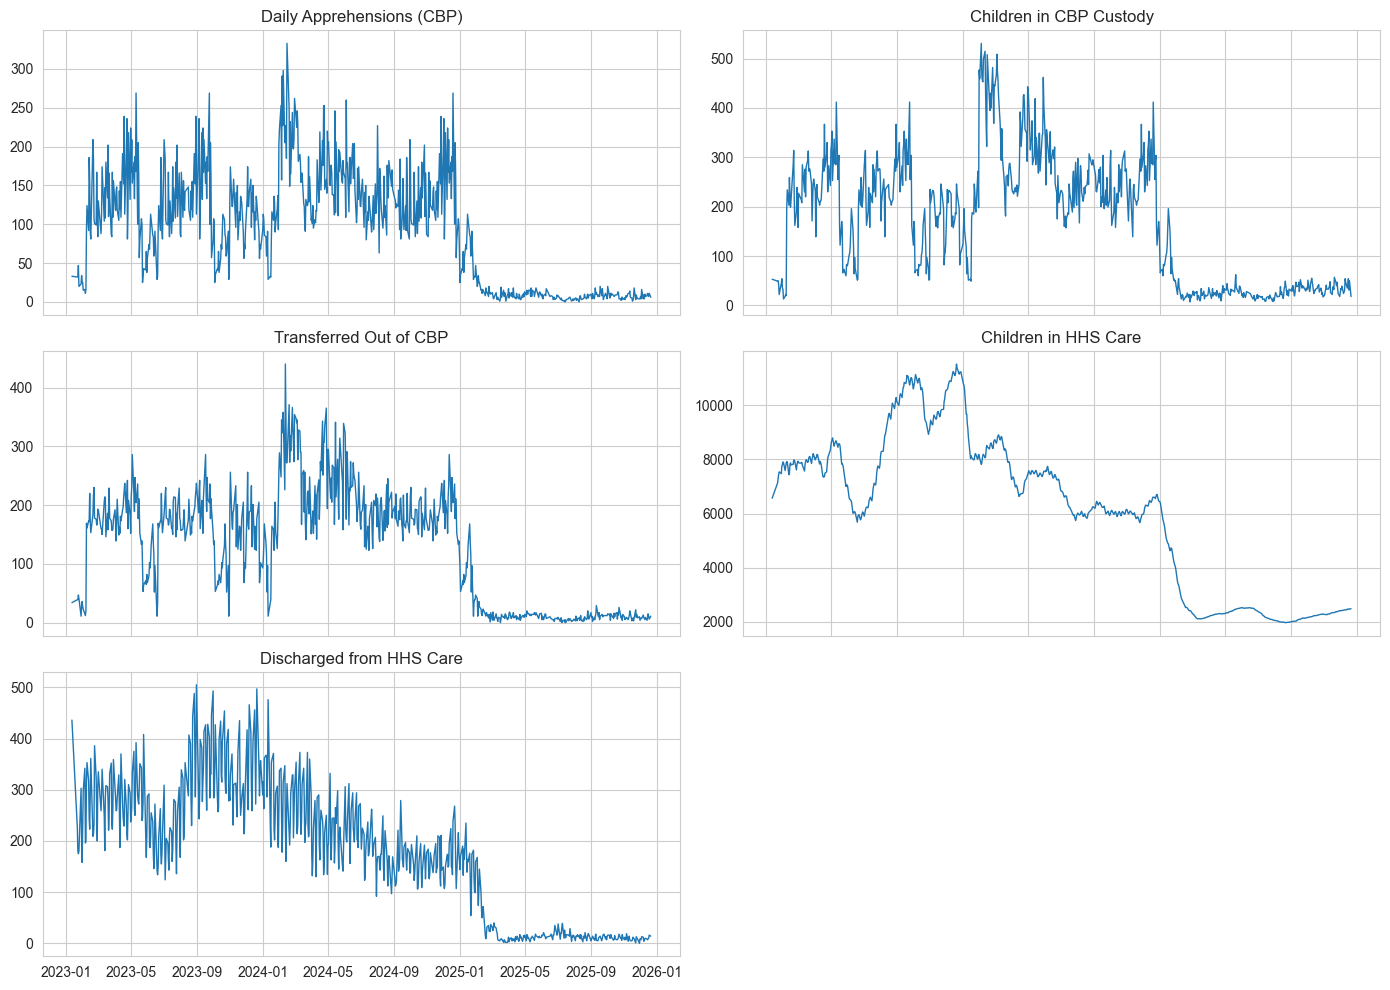

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
cols_to_plot = ["apprehended", "cbp_custody", "transferred_out_cbp", "hhs_care", "discharged"]
titles = ["Daily Apprehensions (CBP)", "Children in CBP Custody", "Transferred Out of CBP",
          "Children in HHS Care", "Discharged from HHS Care"]

for ax, col, title in zip(axes.flat, cols_to_plot, titles):
    ax.plot(df_clean["date"], df_clean[col], linewidth=1)
    ax.set_title(title)

axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()


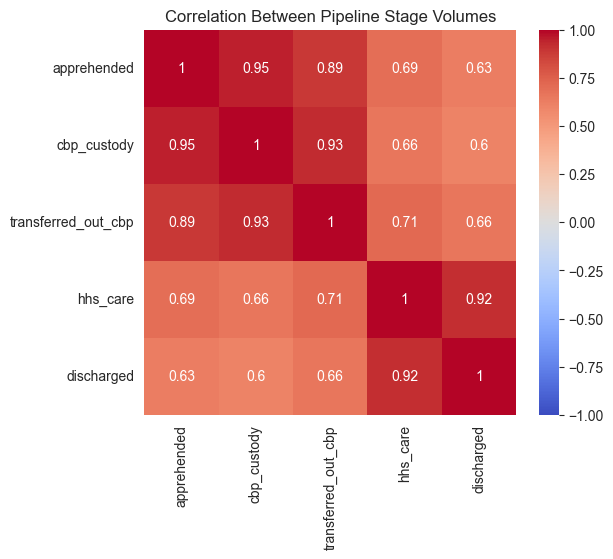

In [9]:
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Pipeline Stage Volumes")
plt.show()


## 4. Care Pipeline Modeling

We represent the system as a flow pipeline with daily stage volumes:

`Apprehended (CBP intake)` → `CBP Custody (active load)` → `Transferred Out of CBP (flow into HHS)` → `HHS Care (active load)` → `Discharged (sponsor placement / exit)`

Each row is one day's snapshot of volumes at each stage.


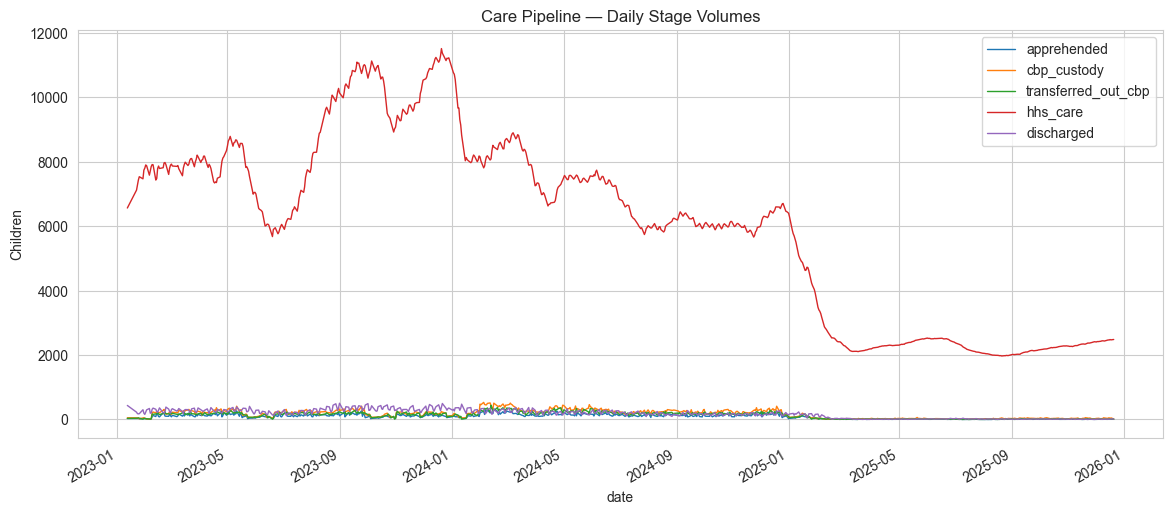

In [10]:
pipeline_cols = ["date", "apprehended", "cbp_custody", "transferred_out_cbp", "hhs_care", "discharged"]
pipeline = df_clean[pipeline_cols].copy()
pipeline.set_index("date").plot(figsize=(14, 6), linewidth=1)
plt.title("Care Pipeline — Daily Stage Volumes")
plt.ylabel("Children")
plt.show()


## 5. Transition Efficiency Metrics

Derived process metrics (as specified in the project brief):

- **Transfer Efficiency Ratio** = Transfers out of CBP ÷ CBP Custody (how much of the active CBP load is being moved to HHS)
- **Discharge Effectiveness** = Discharges ÷ HHS Care (how much of the active HHS load is being placed with sponsors)
- **Pipeline Throughput Rate** = Total exits (discharged) ÷ Total entries (apprehended) — system-level flow balance


In [11]:
pipeline["transfer_efficiency_ratio"] = pipeline["transferred_out_cbp"] / pipeline["cbp_custody"].replace(0, np.nan)
pipeline["discharge_effectiveness"] = pipeline["discharged"] / pipeline["hhs_care"].replace(0, np.nan)

# Pipeline throughput rate — computed as a rolling ratio (30-day) since apprehended/discharged
# are daily flow counts, not cumulative totals
pipeline["throughput_rate_30d"] = (
    pipeline["discharged"].rolling(30).sum() / pipeline["apprehended"].rolling(30).sum()
)

pipeline[["date", "transfer_efficiency_ratio", "discharge_effectiveness", "throughput_rate_30d"]].tail(10)


,date,transfer_efficiency_ratio,discharge_effectiveness,throughput_rate_30d
710,2025-12-08,0.333333,0.001639,1.381443
711,2025-12-09,0.233333,0.003275,1.371134
712,2025-12-10,0.092593,0.003690,1.306931
713,2025-12-11,0.191489,0.004103,1.320197
714,2025-12-14,0.114286,0.003249,1.263415
715,2025-12-15,0.214286,0.002834,1.192488
716,2025-12-16,0.277778,0.003647,1.185185
717,2025-12-17,0.354839,0.004031,1.154545
718,2025-12-18,0.120000,0.006472,1.164444
719,2025-12-21,0.611111,0.005636,1.206278


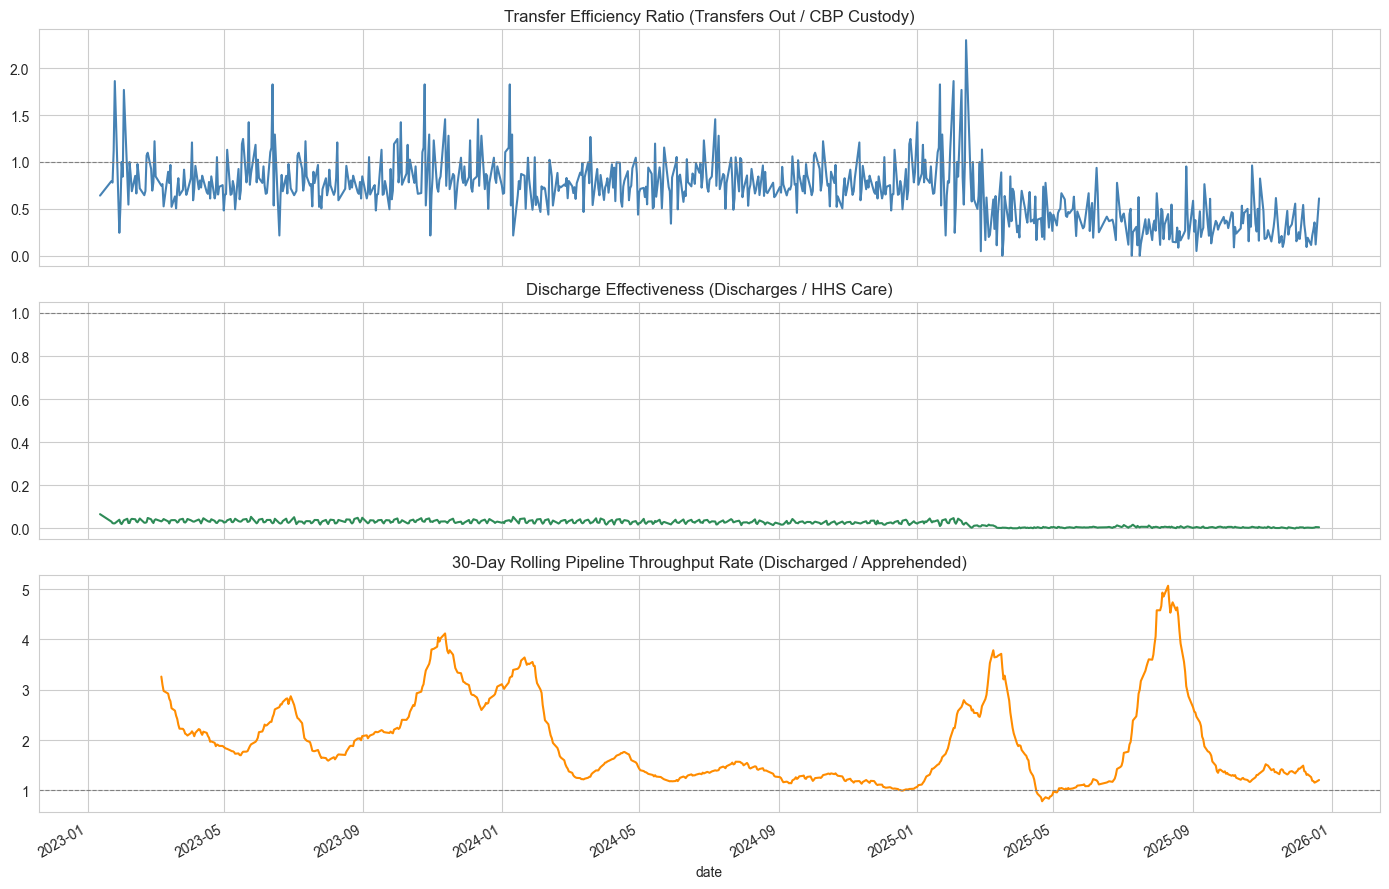

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
pipeline.set_index("date")["transfer_efficiency_ratio"].plot(ax=axes[0], color="steelblue")
axes[0].set_title("Transfer Efficiency Ratio (Transfers Out / CBP Custody)")
axes[0].axhline(1, color="gray", linestyle="--", linewidth=0.8)

pipeline.set_index("date")["discharge_effectiveness"].plot(ax=axes[1], color="seagreen")
axes[1].set_title("Discharge Effectiveness (Discharges / HHS Care)")
axes[1].axhline(1, color="gray", linestyle="--", linewidth=0.8)

pipeline.set_index("date")["throughput_rate_30d"].plot(ax=axes[2], color="darkorange")
axes[2].set_title("30-Day Rolling Pipeline Throughput Rate (Discharged / Apprehended)")
axes[2].axhline(1, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()


## 6. Backlog & Delay Identification

Compare inflow vs. successful exits at each stage to spot sustained imbalance periods
(a proxy for backlog build-up), and flag stretches where the imbalance persists.


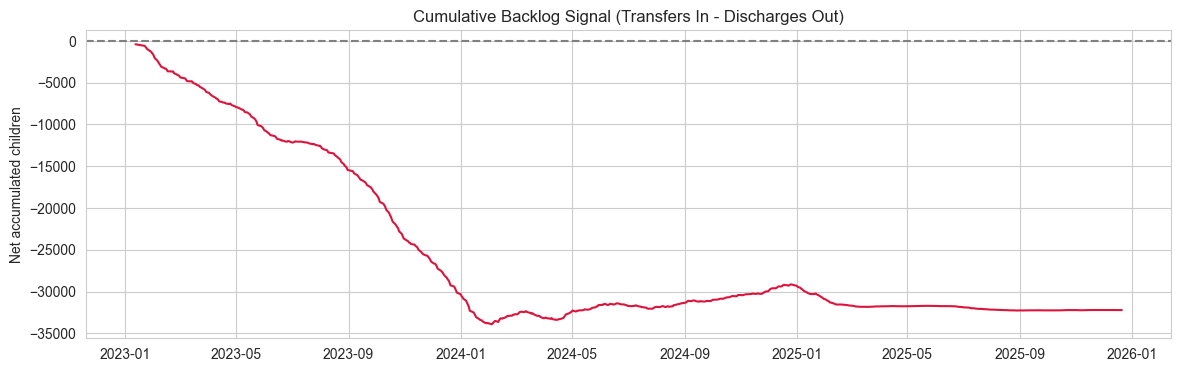

In [13]:
# Net flow into HHS care each day = transferred_out_cbp (in) - discharged (out)
pipeline["net_hhs_flow"] = pipeline["transferred_out_cbp"] - pipeline["discharged"]

# Backlog accumulation = cumulative sum of net flow (rises when inflow > outflow)
pipeline["backlog_accum"] = pipeline["net_hhs_flow"].cumsum()

plt.figure(figsize=(14, 4))
plt.plot(pipeline["date"], pipeline["backlog_accum"], color="crimson")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Cumulative Backlog Signal (Transfers In - Discharges Out)")
plt.ylabel("Net accumulated children")
plt.show()


In [14]:
# Flag sustained imbalance periods: net_hhs_flow > 0 for at least 7 consecutive days
pipeline["imbalance_flag"] = pipeline["net_hhs_flow"] > 0

# Identify consecutive-day streaks of imbalance
pipeline["streak_id"] = (pipeline["imbalance_flag"] != pipeline["imbalance_flag"].shift()).cumsum()
streaks = (
    pipeline[pipeline["imbalance_flag"]]
    .groupby("streak_id")
    .agg(start=("date", "min"), end=("date", "max"), days=("date", "count"))
)
sustained_backlogs = streaks[streaks["days"] >= 7].sort_values("days", ascending=False)
sustained_backlogs.head(10)


,start,end,days
streak_id,,,
70,2024-08-18,2024-09-05,12
44,2024-04-21,2024-05-02,10
48,2024-05-20,2024-06-03,10
90,2024-11-25,2024-12-08,10
104,2025-03-19,2025-03-31,9
46,2024-05-06,2024-05-15,8
86,2024-11-04,2024-11-14,8
82,2024-10-14,2024-10-23,8


## 7. Temporal & Pattern Analysis

Weekday vs. weekend transition speed, and month-over-month trends.


In [15]:
pipeline["weekday"] = pipeline["date"].dt.day_name()
pipeline["is_weekend"] = pipeline["date"].dt.dayofweek >= 5

weekday_summary = pipeline.groupby("weekday")[["transferred_out_cbp", "discharged"]].mean()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = weekday_summary.reindex(weekday_order)
weekday_summary


,transferred_out_cbp,discharged
weekday,,
Monday,123.731034,157.558621
Tuesday,124.859060,136.114094
Wednesday,131.673469,166.013605
Thursday,133.414966,205.687075
Friday,110.000000,144.000000
Saturday,NaN,NaN
Sunday,130.061538,206.138462


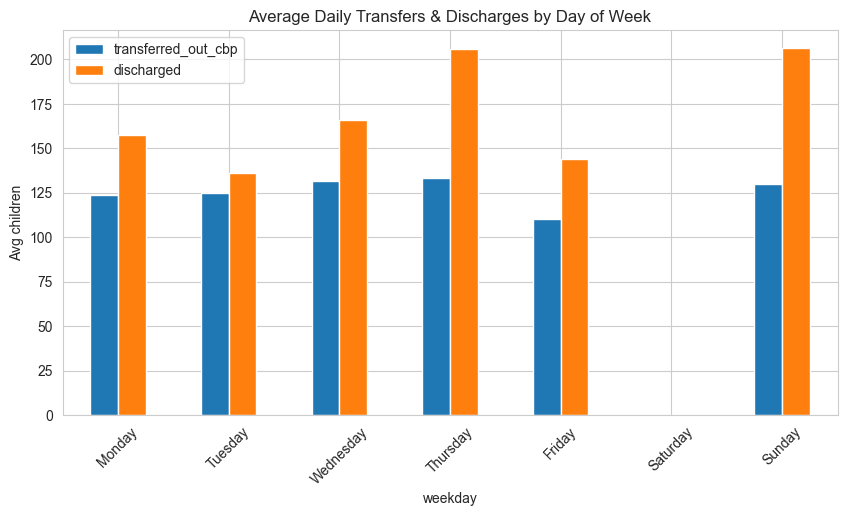

In [16]:
weekday_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Average Daily Transfers & Discharges by Day of Week")
plt.ylabel("Avg children")
plt.xticks(rotation=45)
plt.show()


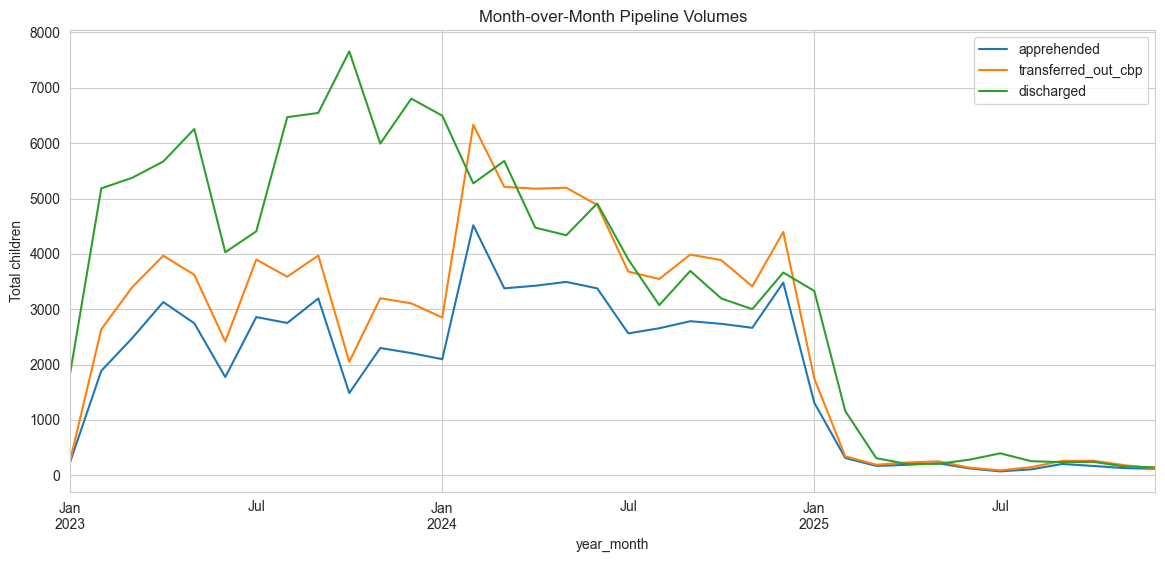

In [17]:
pipeline["year_month"] = pipeline["date"].dt.to_period("M")
monthly = pipeline.groupby("year_month")[["apprehended", "transferred_out_cbp", "discharged"]].sum()
monthly.index = monthly.index.to_timestamp()

monthly.plot(figsize=(14, 6))
plt.title("Month-over-Month Pipeline Volumes")
plt.ylabel("Total children")
plt.show()


## 8. Outcome Stability Analysis

Variability in discharge performance and consistency of placement outcomes over time,
using rolling standard deviation / coefficient of variation as a stability signal.


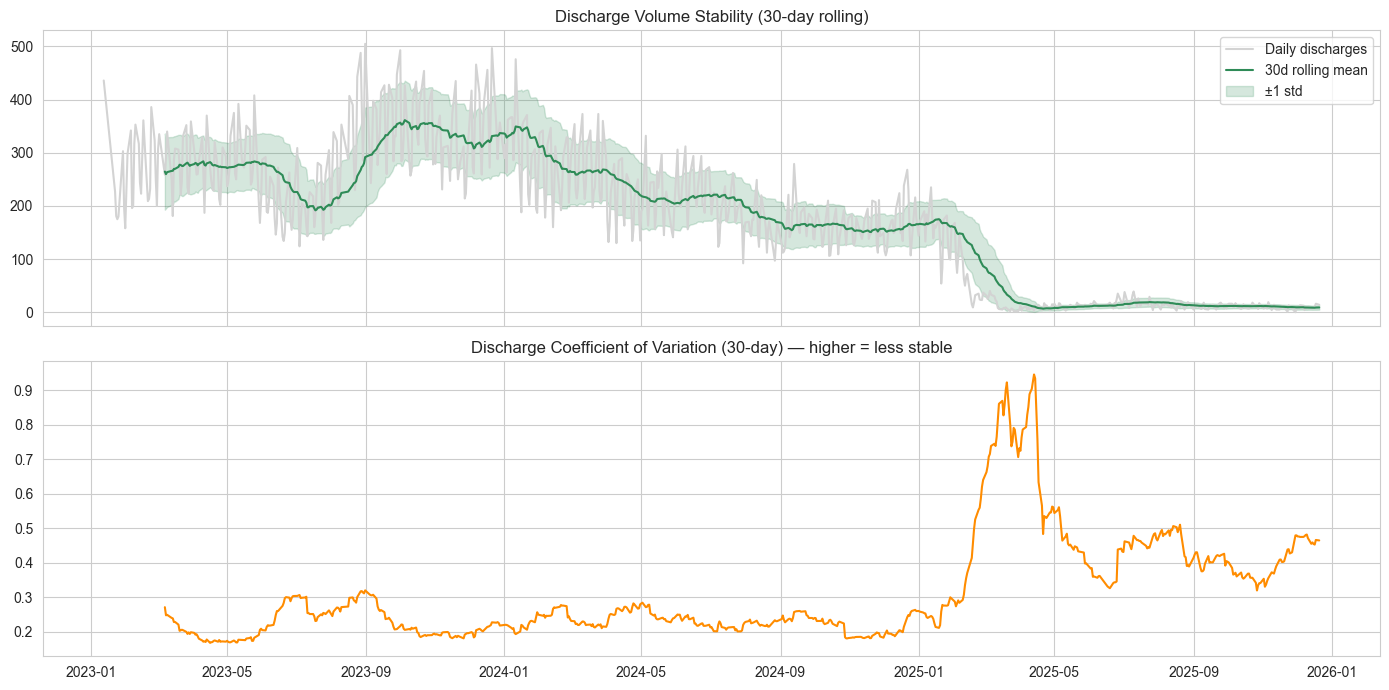

In [18]:
pipeline["discharge_roll_mean_30d"] = pipeline["discharged"].rolling(30).mean()
pipeline["discharge_roll_std_30d"] = pipeline["discharged"].rolling(30).std()
pipeline["discharge_cv_30d"] = pipeline["discharge_roll_std_30d"] / pipeline["discharge_roll_mean_30d"]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(pipeline["date"], pipeline["discharged"], color="lightgray", label="Daily discharges")
axes[0].plot(pipeline["date"], pipeline["discharge_roll_mean_30d"], color="seagreen", label="30d rolling mean")
axes[0].fill_between(pipeline["date"],
                      pipeline["discharge_roll_mean_30d"] - pipeline["discharge_roll_std_30d"],
                      pipeline["discharge_roll_mean_30d"] + pipeline["discharge_roll_std_30d"],
                      color="seagreen", alpha=0.2, label="±1 std")
axes[0].set_title("Discharge Volume Stability (30-day rolling)")
axes[0].legend()

axes[1].plot(pipeline["date"], pipeline["discharge_cv_30d"], color="darkorange")
axes[1].set_title("Discharge Coefficient of Variation (30-day) — higher = less stable")

plt.tight_layout()
plt.show()


In [19]:
# Flag sudden drops in discharge performance: day-over-day drop > 40% vs. prior 7-day average
pipeline["discharge_7d_avg"] = pipeline["discharged"].rolling(7).mean().shift(1)
pipeline["pct_drop_vs_7d"] = (pipeline["discharged"] - pipeline["discharge_7d_avg"]) / pipeline["discharge_7d_avg"]
sudden_drops = pipeline[pipeline["pct_drop_vs_7d"] < -0.4][["date", "discharged", "discharge_7d_avg", "pct_drop_vs_7d"]]
sudden_drops.tail(10)


,date,discharged,discharge_7d_avg,pct_drop_vs_7d
664,2025-09-30,7.0,12.428571,-0.436782
672,2025-10-13,6.0,13.571429,-0.557895
683,2025-10-28,6.0,10.571429,-0.432432
686,2025-11-02,7.0,12.285714,-0.430233
691,2025-11-09,4.0,11.714286,-0.658537
694,2025-11-13,5.0,10.142857,-0.507042
695,2025-11-16,5.0,9.142857,-0.453125
700,2025-11-23,1.0,8.000000,-0.875000
704,2025-11-30,0.0,9.000000,-1.000000
710,2025-12-08,4.0,8.000000,-0.500000


## 9. Key Performance Indicator (KPI) Summary

Final rollup table matching the project's KPI list — this is what the Streamlit dashboard
will surface and let users filter by date range.


In [20]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Transfer Efficiency Ratio (avg)",
        "Discharge Effectiveness Index (avg)",
        "Pipeline Throughput Rate (30d, latest)",
        "Backlog Accumulation (current level)",
        "Outcome Stability Score (avg 30d CV, lower=better)",
    ],
    "Value": [
        round(pipeline["transfer_efficiency_ratio"].mean(), 3),
        round(pipeline["discharge_effectiveness"].mean(), 3),
        round(pipeline["throughput_rate_30d"].dropna().iloc[-1], 3),
        round(pipeline["backlog_accum"].iloc[-1], 1),
        round(pipeline["discharge_cv_30d"].mean(), 3),
    ],
})
kpi_summary


,KPI,Value
0,Transfer Efficiency Ratio (avg),0.691
1,Discharge Effectiveness Index (avg),0.024
2,"Pipeline Throughput Rate (30d, latest)",1.206
3,Backlog Accumulation (current level),-32212.000
4,"Outcome Stability Score (avg 30d CV, lower=bet...",0.310


In [21]:
# Save the cleaned + feature-engineered dataset — this feeds the Streamlit app next
pipeline.to_csv("uac_pipeline_features.csv", index=False)
print("Saved: uac_pipeline_features.csv")
pipeline.tail()


Saved: uac_pipeline_features.csv


,date,apprehended,cbp_custody,transferred_out_cbp,hhs_care,discharged,transfer_efficiency_ratio,discharge_effectiveness,throughput_rate_30d,net_hhs_flow,backlog_accum,imbalance_flag,streak_id,weekday,is_weekend,year_month,discharge_roll_mean_30d,discharge_roll_std_30d,discharge_cv_30d,discharge_7d_avg,pct_drop_vs_7d
715,2025-12-15,11.0,42.0,9.0,2470,7.0,0.214286,0.002834,1.192488,2.0,-32206.0,True,174,Monday,False,2025-12,8.466667,3.883949,0.458734,9.142857,-0.234375
716,2025-12-16,8.0,54.0,15.0,2468,9.0,0.277778,0.003647,1.185185,6.0,-32200.0,True,174,Tuesday,False,2025-12,8.533333,3.875060,0.454109,8.285714,0.086207
717,2025-12-17,7.0,31.0,11.0,2481,10.0,0.354839,0.004031,1.154545,1.0,-32199.0,True,174,Wednesday,False,2025-12,8.466667,3.830309,0.452399,7.857143,0.272727
718,2025-12-18,11.0,50.0,6.0,2472,16.0,0.120000,0.006472,1.164444,-10.0,-32209.0,False,175,Thursday,False,2025-12,8.733333,4.067816,0.465780,8.714286,0.836066
719,2025-12-21,6.0,18.0,11.0,2484,14.0,0.611111,0.005636,1.206278,-3.0,-32212.0,False,175,Sunday,True,2025-12,8.966667,4.164574,0.464451,9.857143,0.420290
